<a href="https://colab.research.google.com/github/HarshithaBoppudi/HarshithaBoppudi-Assignment-03-part4-BITSoM_BA_2511750/blob/main/part4_visualization_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Write the CSV content into a file
csv_data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1
"""

with open("students.csv", "w") as f:
    f.write(csv_data)

**Data Exploration with Pandas**

In [2]:
import pandas as pd

df = pd.read_csv("students.csv")
pd.set_option('display.width', 200)
print("----First 5 rows:----")
print(df.head(),"\n") # Prints the first 5 rows
print(df.dtypes, "\n") # Prints the datatypes


# 2. Print shape and data types
print("----Shape (rows × columns):----", df.shape)


# 3. Summary statistics
print("----Summary statistics:----")
print(df.describe(), "\n")

# 4. Count of students who passed and failed
print("----Pass/Fail counts (via groupby):----")
print(df.groupby('passed').size())

# 5. Average score per subject for passing vs failing students
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("----Average scores for passing students:----")
print(df[df['passed'] == 1][subject_cols].mean(), "\n")

print("----Average scores for failing students:----")
print(df[df['passed'] == 0][subject_cols].mean(), "\n")

# 6. Student with highest overall average across subjects
df['avg_score'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['avg_score'].idxmax()]

print("----Student with highest overall average:----")
print(top_student[['name', 'avg_score']])


----First 5 rows:----
      name  math  science  english  history  pe  attendance_pct  study_hours_per_day  passed
0    Alice    88       92       76       80  95              92                  4.5       1
1      Bob    42       55       48       50  60              65                  1.2       0
2  Charlie    75       70       80       68  88              85                  3.0       1
3    Diana    95       98       91       89  97              98                  6.0       1
4      Eve    38       42       50       45  55              58                  0.8       0 

name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object 

----Shape (rows × columns):---- (15, 9)
----Summary statistics:----
            math    science    english    history      

** Data Visualization with Matplotlib**

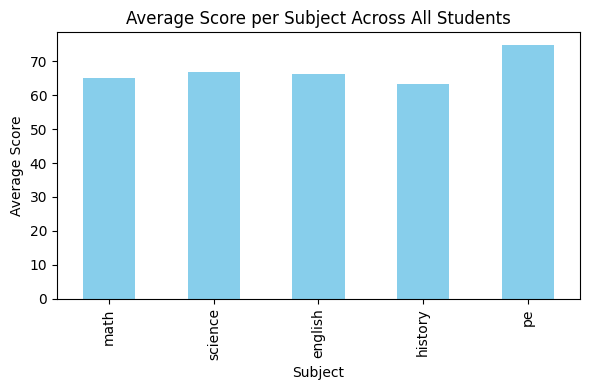

In [3]:
import matplotlib.pyplot as plt

# Add avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1. Bar Chart — Average score per subject
plt.figure(figsize=(6,4))
df[subject_cols].mean().plot(kind='bar', color='skyblue')
plt.title("Average Score per Subject Across All Students")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.tight_layout()
plt.savefig("plot1_bar.png")
plt.show()

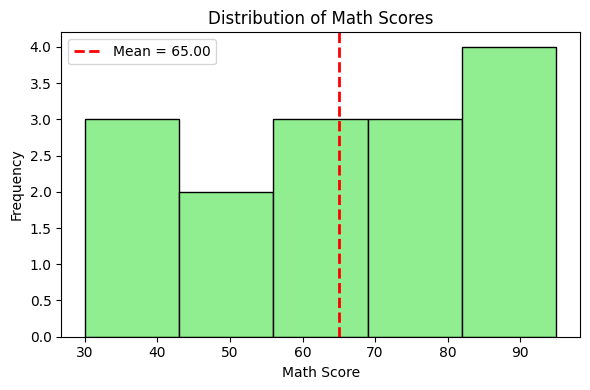

In [4]:
# 2. Histogram — Distribution of math scores
plt.figure(figsize=(6,4))
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black')
mean_math = df['math'].mean()
plt.axvline(mean_math, color='red', linestyle='dashed', linewidth=2, label=f"Mean = {mean_math:.2f}")
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("plot2_histogram.png")
plt.show()


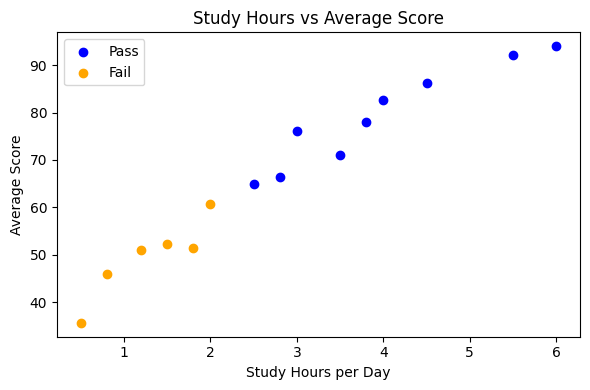

In [5]:
# 3. Scatter Plot — study_hours_per_day vs avg_score
plt.figure(figsize=(6,4))
plt.scatter(df[df['passed']==1]['study_hours_per_day'], df[df['passed']==1]['avg_score'],
            color='blue', label='Pass')
plt.scatter(df[df['passed']==0]['study_hours_per_day'], df[df['passed']==0]['avg_score'],
            color='orange', label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("plot3_scatter.png")
plt.show()

/tmp/ipykernel_3844/1896115924.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


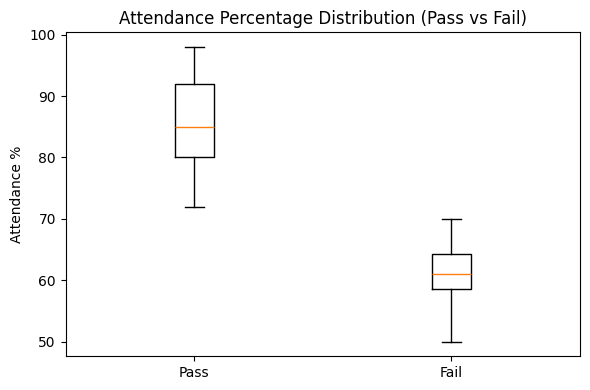

In [6]:
# 4. Box Plot — Attendance % for Pass vs Fail
pass_attendance = df[df['passed']==1]['attendance_pct'].tolist()
fail_attendance = df[df['passed']==0]['attendance_pct'].tolist()
plt.figure(figsize=(6,4))
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title("Attendance Percentage Distribution (Pass vs Fail)")
plt.ylabel("Attendance %")
plt.tight_layout()
plt.savefig("plot4_box.png")
plt.show()

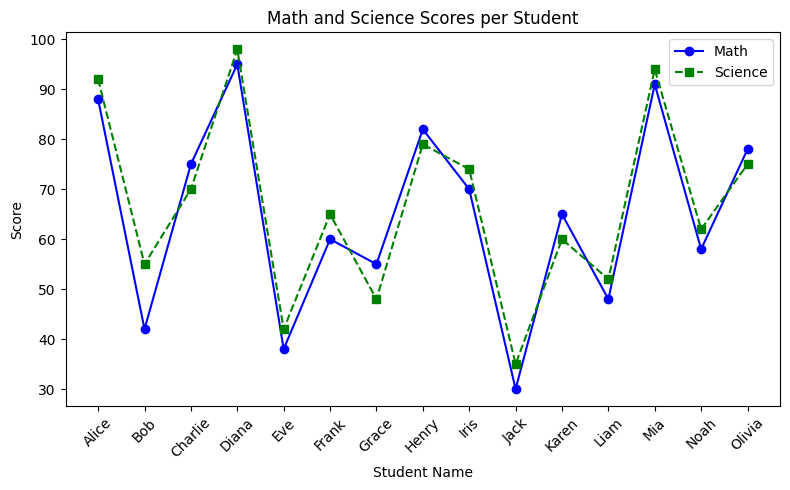

In [7]:
# 5. Line Plot — Math vs Science scores per student
plt.figure(figsize=(8,5))
plt.plot(df['name'], df['math'], marker='o', linestyle='-', color='blue', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', color='green', label='Science')
plt.title("Math and Science Scores per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

**Data Visualization with Seaborn **

/tmp/ipykernel_3844/3325439194.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='Blues')
/tmp/ipykernel_3844/3325439194.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Fail','Pass'])
/tmp/ipykernel_3844/3325439194.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='Greens')
/tmp/ipykernel_3844/3325439194.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Fail','Pass'])


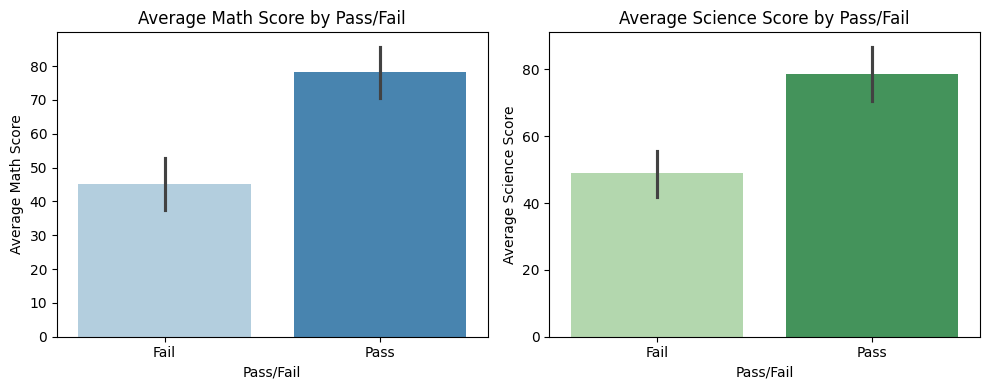

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Bar Plots (Math & Science scores split by Pass/Fail) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))

sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='Blues')
ax1.set_title("Average Math Score by Pass/Fail")
ax1.set_xlabel("Pass/Fail")
ax1.set_ylabel("Average Math Score")
ax1.set_xticklabels(['Fail','Pass'])

sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='Greens')
ax2.set_title("Average Science Score by Pass/Fail")
ax2.set_xlabel("Pass/Fail")
ax2.set_ylabel("Average Science Score")
ax2.set_xticklabels(['Fail','Pass'])

plt.tight_layout()
plt.savefig("task3_barplots.png")
plt.show()


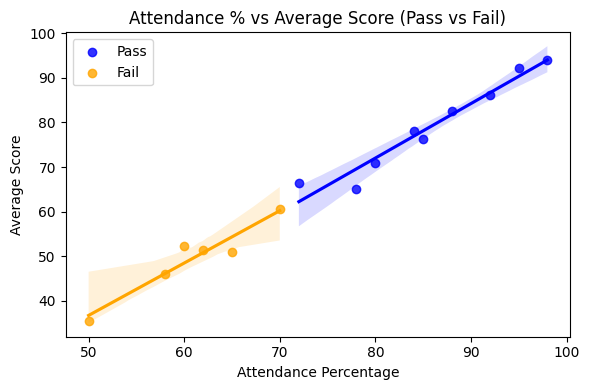

In [9]:
# --- 2. Scatter Plot with Regression Lines ---
plt.figure(figsize=(6,4))

sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score',
            scatter=True, label='Pass', color='blue')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score',
            scatter=True, label='Fail', color='orange')

plt.title("Attendance % vs Average Score (Pass vs Fail)")
plt.xlabel("Attendance Percentage")
plt.ylabel("Average Score")
plt.legend()
plt.tight_layout()
plt.savefig("task3_scatter_regression.png")
plt.show()

# --- Reflection ---
# Compared to Matplotlib, Seaborn made it easier to create visually appealing plots
# with fewer lines of code (e.g., barplot and regplot automatically handle means and regression lines).
# However, customizing details like axis labels and tick names still required Matplotlib commands.

**Machine Learning with scikit-learn **

Training Accuracy: 1.0
Test Accuracy: 1.0
Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct

Feature Importance (sorted by absolute value):
english: 0.813 (Pass)
attendance_pct: 0.522 (Pass)
study_hours_per_day: 0.484 (Pass)
pe: 0.475 (Pass)
math: 0.438 (Pass)
science: 0.323 (Pass)
history: 0.263 (Pass)


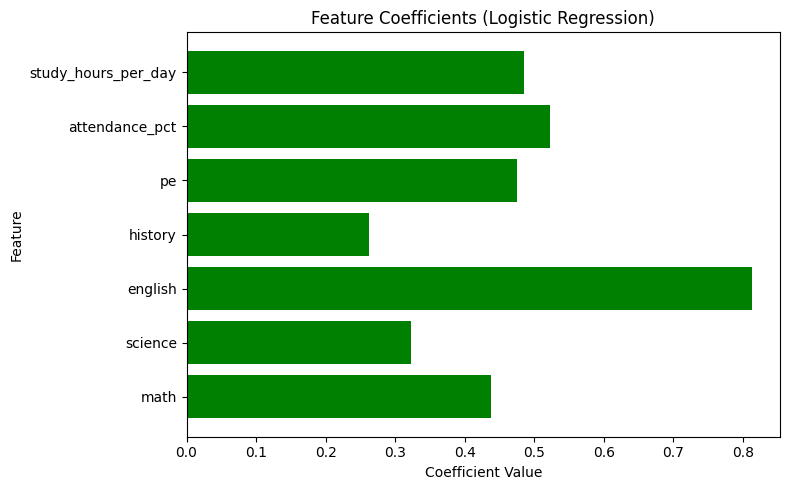


New Student Prediction:
Predicted: Pass
Probabilities [Fail, Pass]: [0.09203526 0.90796474]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Step 1 — Prepare Data
subject_cols = ['math', 'science', 'english', 'history', 'pe']
X = df[subject_cols + ['attendance_pct', 'study_hours_per_day']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Step 2 — Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

print("Training Accuracy:", model.score(X_train_scaled, y_train))

# Step 3 — Evaluate Model
y_pred = model.predict(X_test_scaled)
print("Test Accuracy:", model.score(X_test_scaled, y_test))

# Print predictions with names
names = df.loc[X_test.index, 'name']
for name, actual, pred in zip(names, y_test, y_pred):
    status = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"{name}: Actual={actual}, Predicted={pred} → {status}")

# Step 4 — Feature Importance
coefficients = model.coef_[0]
feature_importance = sorted(
    zip(X.columns, coefficients), key=lambda x: abs(x[1]), reverse=True
)

print("\nFeature Importance (sorted by absolute value):")
for feat, coef in feature_importance:
    direction = "Pass" if coef > 0 else "Fail"
    print(f"{feat}: {coef:.3f} ({direction})")

    # Plot coefficients
plt.figure(figsize=(8,5))
colors = ['green' if c > 0 else 'red' for c in coefficients]
plt.barh(X.columns, coefficients, color=colors)
plt.title("Feature Coefficients (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("task4_feature_importance.png")
plt.show()

# Step 5 — Predict for a New Student (Bonus)
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]  # order matches X columns
new_student_scaled = scaler.transform(new_student)
prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

print("\nNew Student Prediction:")
print("Predicted:", "Pass" if prediction == 1 else "Fail")
print("Probabilities [Fail, Pass]:", probability)